# AI Prepardness Index

AI Preparedness Index (AIPI) assesses the level of AI preparedness across 174 countries, based on a rich set of macro-structural indicators that cover the countries’ digital infrastructure, human capital and labor market policies, innovation and economic integration, and regulation and ethics.

In [ ]:
import pandas as pd

aipi_df = pd.read_excel('./aipidata.xlsx', header=1)
aipi_df = aipi_df.rename(columns={'Digitial Infrastructure': 'Digital Infrastructure'})

display(aipi_df.head())
print("\nGhana in dataset:", "Ghana" in aipi_df["Country"].values)

,Country,iso3,type,AIPI,Digital Infrastructure,Innovation and Economic Integration,Human Capital and Labor Market Policies,Regulation and Ethics
0,Australia,AUS,AE,0.727100,0.182183,0.161901,0.171242,0.211774
1,Austria,AUT,AE,0.724566,0.193743,0.173843,0.159031,0.197948
2,Belgium,BEL,AE,0.672478,0.174678,0.172373,0.164082,0.161345
3,Canada,CAN,AE,0.713151,0.171950,0.160842,0.174783,0.205577
4,Croatia,HRV,AE,0.581696,0.172187,0.139786,0.126231,0.143492



Ghana in dataset: True


Ghana's overall AI Preparedness Index


In [ ]:
# Ghana's AI Preparedness Index
ghana_aipi = aipi_df.loc[aipi_df['Country'] == 'Ghana', 'AIPI'].values[0]
ghana_aipi_percent = (ghana_aipi * 100).round(2).astype(str) + '%'

print(f"Ghana's AIPI: {ghana_aipi:.4f}")
print(f"Ghana's AI Preparedness Index is {ghana_aipi_percent}")

Ghana's AIPI: 0.4252
Ghana's AI Preparedness Index is 42.52%


WGhana's weakest and strongest pillars

In [ ]:
ghana_data = aipi_df[aipi_df['Country'] == 'Ghana']

pillar_cols = [
    'Digital Infrastructure',
    'Innovation and Economic Integration',
    'Human Capital and Labor Market Policies',
    'Regulation and Ethics'
]

ghana_pillars_df = pd.DataFrame({
    'Pillar': pillar_cols,
    'Index': ghana_data.iloc[0][pillar_cols].values
}).sort_values(by='Index', ascending=False).reset_index(drop=True)

# Percent
ghana_pillars_df['Percentage'] = (ghana_pillars_df['Index'] * 100).map('{:.2f}%'.format)

print("Ghana's Pillar Scores DataFrame:")
display(ghana_pillars_df)

print(f"\nStrongest: {ghana_pillars_df.iloc[0]['Pillar']} ({ghana_pillars_df.iloc[0]['Index']:.4f})")
print(f"Weakest:   {ghana_pillars_df.iloc[-1]['Pillar']} ({ghana_pillars_df.iloc[-1]['Index']:.4f})")

Ghana's Pillar Scores DataFrame:


,Pillar,Index,Percentage
0,Regulation and Ethics,0.133843,13.38%
1,Human Capital and Labor Market Policies,0.113733,11.37%
2,Innovation and Economic Integration,0.088968,8.90%
3,Digital Infrastructure,0.088655,8.87%



Strongest: Regulation and Ethics (0.1338)
Weakest:   Digital Infrastructure (0.0887)


### Ghana's Rank Within Africa
Finding how Ghana compares to all other African nations in the dataset.

In [ ]:
african_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon',
    'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep. of the', 'Congo, Republic of',
    "Cote d'Ivoire", 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia',
    'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia',
    'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique',
    'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles',
    'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo',
    'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

africa_df = aipi_df[aipi_df['Country'].isin(african_countries)].sort_values('AIPI', ascending=False).reset_index(drop=True)

africa_df['AIPI %'] = (africa_df['AIPI'] * 100).round(2).astype(str) + '%'
africa_df['Rank'] = africa_df.index + 1

# Ghana's stats
ghana_rank = africa_df.loc[africa_df['Country'] == 'Ghana', 'Rank'].values[0]
total_africa = len(africa_df)

print(f"Ghana's Rank in Africa: {ghana_rank} out of {total_africa}\n")
display(africa_df[['Country', 'AIPI', 'AIPI %', 'Rank']].head(10))

Ghana's Rank in Africa: 9 out of 48



,Country,AIPI,AIPI %,Rank
0,Seychelles,0.530653,53.07%,1
1,Mauritius,0.525113,52.51%,2
2,South Africa,0.496765,49.68%,3
3,Tunisia,0.465410,46.54%,4
4,Kenya,0.445192,44.52%,5
5,Rwanda,0.437400,43.74%,6
6,Cabo Verde,0.432587,43.26%,7
7,Morocco,0.429111,42.91%,8
8,Ghana,0.425200,42.52%,9
9,Namibia,0.419612,41.96%,10


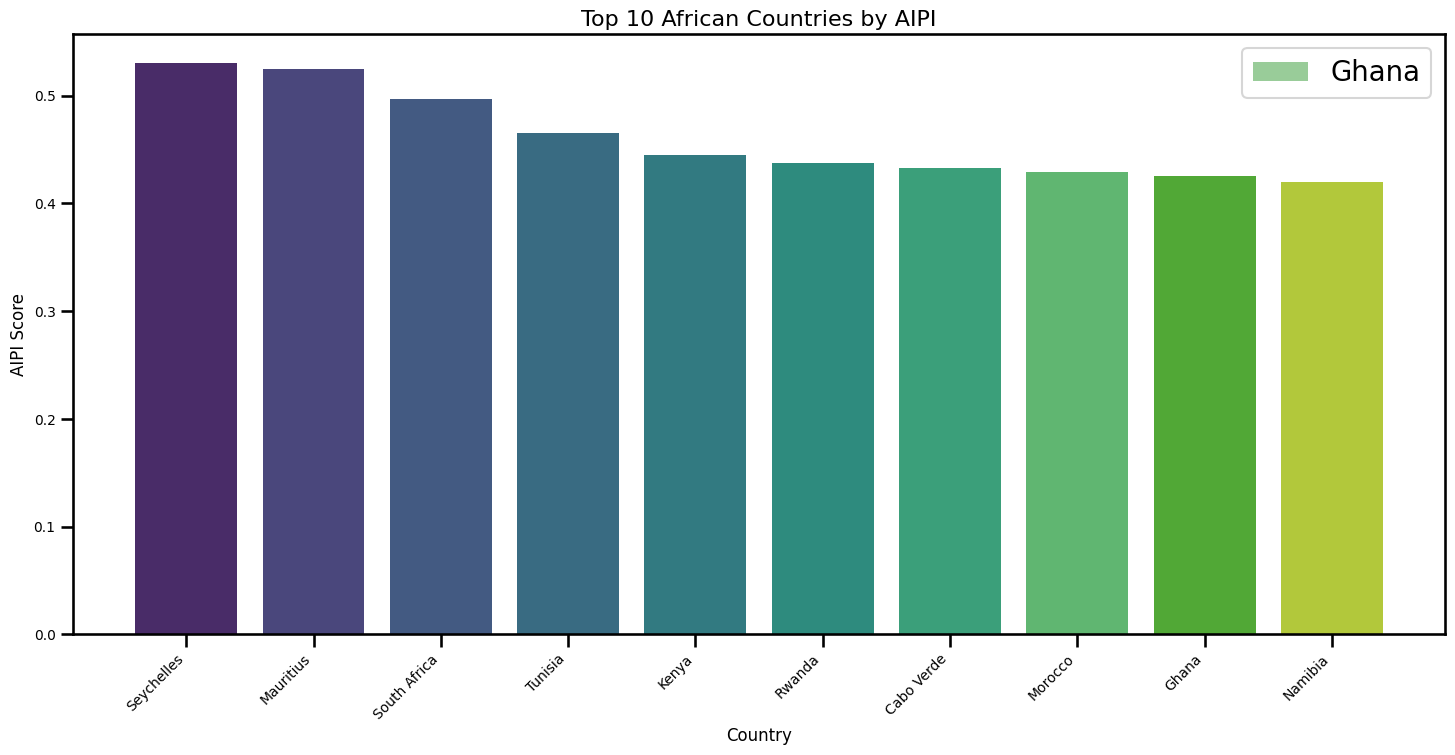

In [ ]:
africa_df = aipi_df[aipi_df['Country'].isin(african_countries)].sort_values('AIPI', ascending=False).reset_index(drop=True)

africa_df['AIPI %'] = (africa_df['AIPI'] * 100).round(2).astype(str) + '%'
africa_df['Rank'] = africa_df.index + 1

fig = plt.figure(figsize=(15, 8))
sns.barplot(
x='Country',
y='AIPI',
data=africa_df.head(10),
palette='viridis',
hue='Country',
legend=False
)

plt.title('Top 10 African Countries by AIPI', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('AIPI Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

ghana_bar = africa_df[africa_df['Country'] == 'Ghana']
if not ghana_bar.empty:
    ghana_pos = africa_df.index[africa_df['Country'] == 'Ghana'][0]
    if ghana_pos < 10:
        plt.bar(x=ghana_pos, height=ghana_bar['AIPI'].values[0], color='green', label='Ghana', alpha=0.4)
        plt.legend()

plt.tight_layout()
plt.show()

### Global Comparison
Comparing Ghana's AIPI score against the top 10 countries in the world.

Ghana ranks 99th globally with an AIPI score of 0.4252.

In comparison to the top 10 global leaders, there is a notable gap. Singapore leads the index with a score of 0.8006, nearly double that of Ghana. The top 5 is rounded out by Denmark, the United States, the Netherlands, and Estonia.

In [ ]:
aipi_global_df = aipi_df.dropna(subset=['AIPI']).copy()

# Global Rank
aipi_global_df['Rank'] = aipi_global_df['AIPI'].rank(ascending=False, method='min').astype(int)
top_10 = aipi_global_df.sort_values('AIPI', ascending=False).head(10)
ghana_index = aipi_global_df[aipi_global_df['Country'] == 'Ghana']

# Percentage
comparison_df = pd.concat([top_10, ghana_index]).reset_index(drop=True)
comparison_df['AIPI %'] = (comparison_df['AIPI'] * 100).round(2).astype(str) + '%'

print("Ghana vs Top 10 Global Leaders")
display(comparison_df[['Country', 'AIPI', 'AIPI %', 'Rank']])

Ghana vs Top 10 Global Leaders


,Country,AIPI,AIPI %,Rank
0,Singapore,0.800567,80.06%,1
1,Denmark,0.778522,77.85%,2
2,United States,0.771269,77.13%,3
3,Netherlands,0.766493,76.65%,4
4,Estonia,0.764382,76.44%,5
5,Finland,0.758017,75.8%,6
6,Switzerland,0.757012,75.7%,7
7,New Zealand,0.753680,75.37%,8
8,Germany,0.753329,75.33%,9
9,Sweden,0.747800,74.78%,10


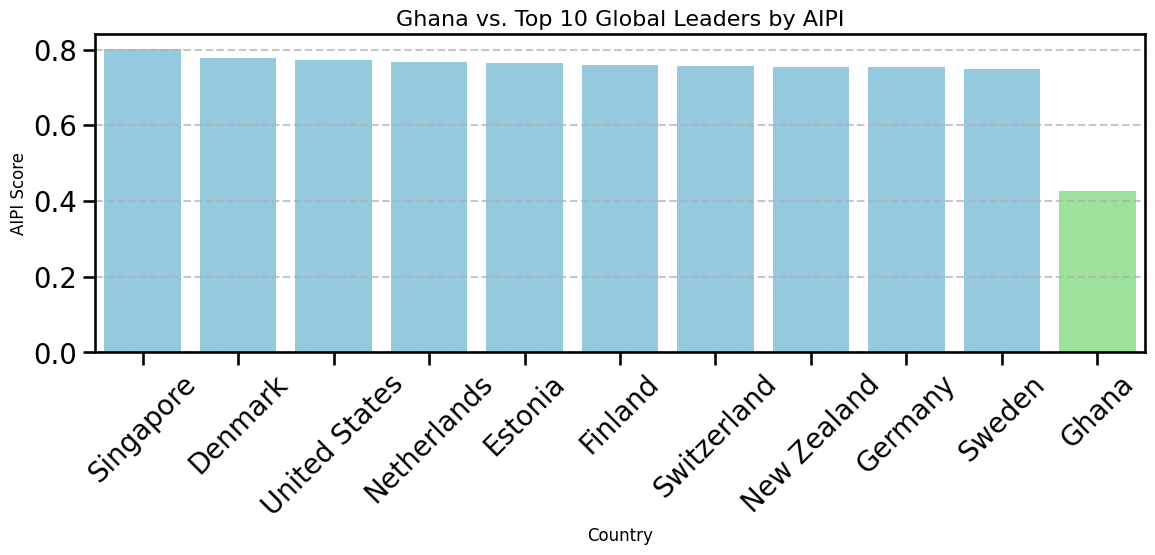

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

aipi_global_df = aipi_df.dropna(subset=['AIPI']).copy()
aipi_global_df['Rank'] = aipi_global_df['AIPI'].rank(ascending=False, method='min').astype(int)
top_10 = aipi_global_df.sort_values('AIPI', ascending=False).head(10)
ghana_index = aipi_global_df[aipi_global_df['Country'] == 'Ghana']
comparison_df = pd.concat([top_10, ghana_index]).reset_index(drop=True)

plot_df = comparison_df.sort_values('AIPI', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
colors = ['lightgreen' if x == 'Ghana' else 'skyblue' for x in plot_df['Country']]

sns.barplot(x='Country', y='AIPI', data=plot_df, palette=colors, hue='Country', legend=False)

plt.title("Ghana vs. Top 10 Global Leaders by AIPI", fontsize=16)
plt.ylabel('AIPI Score', fontsize=12)
plt.xlabel('Country', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Top 10 average vs Ghana

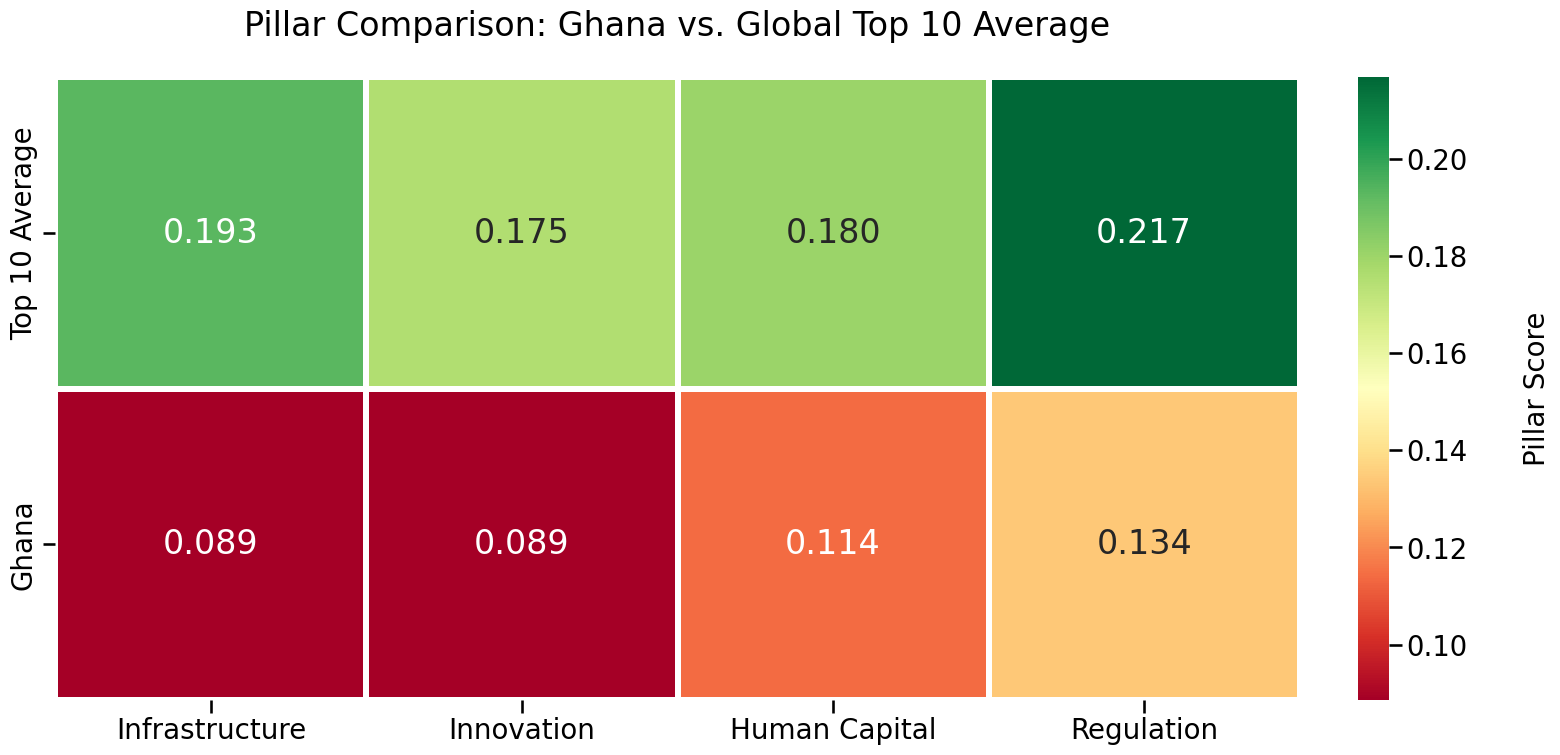

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pillar_cols = [
    'Digital Infrastructure',
    'Innovation and Economic Integration',
    'Human Capital and Labor Market Policies',
    'Regulation and Ethics'
]

# Data i.e. Ghana vs Top 10 avg
top_10_avg = aipi_global_df.sort_values('AIPI', ascending=False).head(10)[pillar_cols].mean()
ghana_index_value = aipi_global_df[aipi_global_df['Country'] == 'Ghana'][pillar_cols].iloc[0]

heatmap_df = pd.DataFrame({
    'Top 10 Average': top_10_avg,
    'Ghana': ghana_index_value
}).T

# Renaming labels
pillar_cols_labels = ['Infrastructure', 'Innovation', 'Human Capital', 'Regulation']

# Setting up figure
plt.figure(figsize=(20, 8))
sns.set_context('talk', font_scale=1.2)

# Heatmap
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    cmap='RdYlGn',
    fmt='.3f',
    square=True,
    linewidths=3,
    annot_kws={'size': 24},
    xticklabels=pillar_cols_labels,
    cbar_kws={'pad': 0.03}
)

cbar = ax.collections[0].colorbar
cbar.set_label('Pillar Score', labelpad=40, size=20)

plt.title('Pillar Comparison: Ghana vs. Global Top 10 Average', fontsize=24, pad=30)
plt.xticks(fontsize=20, rotation=0)
plt.yticks(fontsize=20, rotation=90)

plt.tight_layout()
plt.show()

Regulation and Ethics: This is Ghana's highest-scoring pillar (0.134). While still significantly lower than the global leaders' average (0.217), it represents the area where Ghana has its strongest framework for AI preparedness.
Digital Infrastructure: This is the area with the widest relative gap. The global leaders average 0.193, while Ghana is at 0.089. This suggests that foundational access to high-speed internet and reliable data centers remains the most critical barrier for Ghana.
Human Capital: Ghana's score of 0.114 compared to the leaders' 0.180 indicates a need for continued investment in digital literacy and specialized AI skills within the workforce.
Innovation and Economic Integration: Ghana scores 0.089 here, nearly half of the global average (0.175). This reflects the challenges in integrating AI into the local business ecosystem and fostering home-grown tech innovation.

### Global AI Preparedness Index

In [ ]:
import plotly.express as px

fig = px.choropleth(
    aipi_global_df,
    locations="iso3",
    color="AIPI",
    hover_name="Country",
    color_continuous_scale=px.colors.diverging.RdYlGn,
    title='Global AI Preparedness Index (AIPI) Distribution',
    labels={'AIPI': 'AIPI Score'}
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    coloraxis_colorbar=dict(
        title="AIPI",
        thicknessmode="pixels", thickness=15,
        lenmode="fraction", len=0.5,
        yanchor="top", y=0.8
    )
)

fig.show()